# NumCompute Stream — Streaming Demo

This notebook demonstrates the full NumCompute Stream pipeline:

1. Load a dataset from a CSV file using `io.py`
2. Split into multiple chunks to simulate streaming data
3. Train models incrementally using `.partial_fit()` on each chunk
4. Log and visualise key metrics over time using `visualise.py`
5. Compare single tree vs ensemble (Bagging, Random Forest)

Only NumPy and matplotlib are used — no scikit-learn, no pandas.

In [3]:
%pip install matplotlib

import sys
from pathlib import Path

# Ensure the project root is on the path
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {'demo', 'numcompute_stream'}:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import tempfile
import os

# NumCompute Stream modules
from numcompute_stream.preprocessing import StreamingStandardScaler
from numcompute_stream.tree import StreamingDecisionTree
from numcompute_stream.ensemble import StreamingBaggingClassifier, StreamingRandomForest
from numcompute_stream import visualise

print('NumCompute Stream demo loaded.')

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 3.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 2.8 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 2.8 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 2.8 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.2 MB 2.8 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.2 MB 2.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 2.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 2.8 MB/s eta 0:00:01
   -----------------------

## 1. Generate and load a synthetic CSV dataset

We generate a synthetic binary classification dataset and save it as a CSV,
then load it back using NumPy — simulating a real-world CSV ingestion scenario.

In [4]:
rng = np.random.default_rng(seed=2024)

N = 2000
N_FEATURES = 8

X_raw = rng.standard_normal((N, N_FEATURES))
# Non-linear boundary: class 1 if (x0 + x1 - 0.5*x2^2 + noise) > 0
noise = 0.4 * rng.standard_normal(N)
y_raw = ((X_raw[:, 0] + X_raw[:, 1] - 0.5 * X_raw[:, 2]**2 + noise) > 0).astype(int)

# Introduce ~5% missing values in features
missing_mask = rng.random((N, N_FEATURES)) < 0.05
X_missing = X_raw.copy()
X_missing[missing_mask] = np.nan

# Save to a temporary CSV
csv_path = os.path.join(tempfile.gettempdir(), 'stream_demo_data.csv')
data_with_labels = np.column_stack([X_missing, y_raw])
np.savetxt(csv_path, data_with_labels, delimiter=',', fmt='%.6f')
print(f'Dataset saved to {csv_path}')
print(f'Shape: {X_raw.shape} | Class balance: {y_raw.mean():.2%} positive')

Dataset saved to C:\Users\rupes\AppData\Local\Temp\stream_demo_data.csv
Shape: (2000, 8) | Class balance: 39.95% positive


In [5]:
# Load back with NumPy (simulating io.py load_csv)
raw = np.genfromtxt(csv_path, delimiter=',', filling_values=np.nan)
X = raw[:, :-1]
y = raw[:, -1].astype(int)
print(f'Loaded: X.shape={X.shape}, y.shape={y.shape}')
print(f'Missing values in X: {np.isnan(X).sum()} ({np.isnan(X).mean():.1%})')

Loaded: X.shape=(2000, 8), y.shape=(2000,)
Missing values in X: 770 (4.8%)


## 2. Split into streaming chunks

We simulate a data stream by splitting the dataset into equal-size chunks.
Each chunk is presented to the models one at a time — no future data is seen.

In [6]:
CHUNK_SIZE = 100
CLASSES = np.array([0, 1])

# Split into chunks; drop the incomplete last chunk for clean reporting
n_chunks = len(X) // CHUNK_SIZE
chunks = [(X[i*CHUNK_SIZE:(i+1)*CHUNK_SIZE], y[i*CHUNK_SIZE:(i+1)*CHUNK_SIZE])
          for i in range(n_chunks)]

print(f'Total samples : {len(X)}')
print(f'Chunk size    : {CHUNK_SIZE}')
print(f'Num chunks    : {n_chunks}')

Total samples : 2000
Chunk size    : 100
Num chunks    : 20


## 3. Incremental training with `partial_fit`

Three models are trained in parallel:
- A single `StreamingDecisionTree`
- A `StreamingBaggingClassifier` (5 trees)
- A `StreamingRandomForest` (5 trees, sqrt features)

For each chunk we:
1. Update the scaler with `partial_fit`
2. Scale the chunk
3. Update each model with `partial_fit`
4. Evaluate on the **full scaled dataset** and log accuracy, F1

In [7]:
def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def f1_binary(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

# Initialise models
scaler = StreamingStandardScaler()

models = {
    'Decision Tree': StreamingDecisionTree(
        min_samples_split=30, delta=1e-5, max_depth=10, random_state=0),
    'Bagging (5 trees)': StreamingBaggingClassifier(
        n_estimators=5, min_samples_split=30, delta=1e-5, max_depth=10, random_state=0),
    'Random Forest (5 trees)': StreamingRandomForest(
        n_estimators=5, max_features='sqrt', min_samples_split=30,
        delta=1e-5, max_depth=10, random_state=0),
}

# Metric log: {model_name: {'accuracy': [...], 'f1': [...]}}
logs = {name: {'accuracy': [], 'f1': []} for name in models}

# --- Streaming loop ---
for chunk_idx, (Xc, yc) in enumerate(chunks):
    # Impute NaN with column mean from the scaler's running stats
    scaler.partial_fit(Xc)
    Xc_clean = np.where(np.isnan(Xc), scaler.mean_, Xc)
    Xc_scaled = scaler.transform(Xc_clean)

    for name, model in models.items():
        model.partial_fit(Xc_scaled, yc, classes=CLASSES)

    # Evaluate on entire dataset (scaled with current scaler)
    X_clean = np.where(np.isnan(X), scaler.mean_, X)
    X_scaled = scaler.transform(X_clean)
    for name, model in models.items():
        preds = model.predict(X_scaled)
        logs[name]['accuracy'].append(accuracy(y, preds))
        logs[name]['f1'].append(f1_binary(y, preds))

print(f'Training complete. Final accuracies:')
for name, log in logs.items():
    print(f'  {name}: {log["accuracy"][-1]:.3f}')

Training complete. Final accuracies:
  Decision Tree: 0.842
  Bagging (5 trees): 0.876
  Random Forest (5 trees): 0.713


## 4. Visualise metrics over time

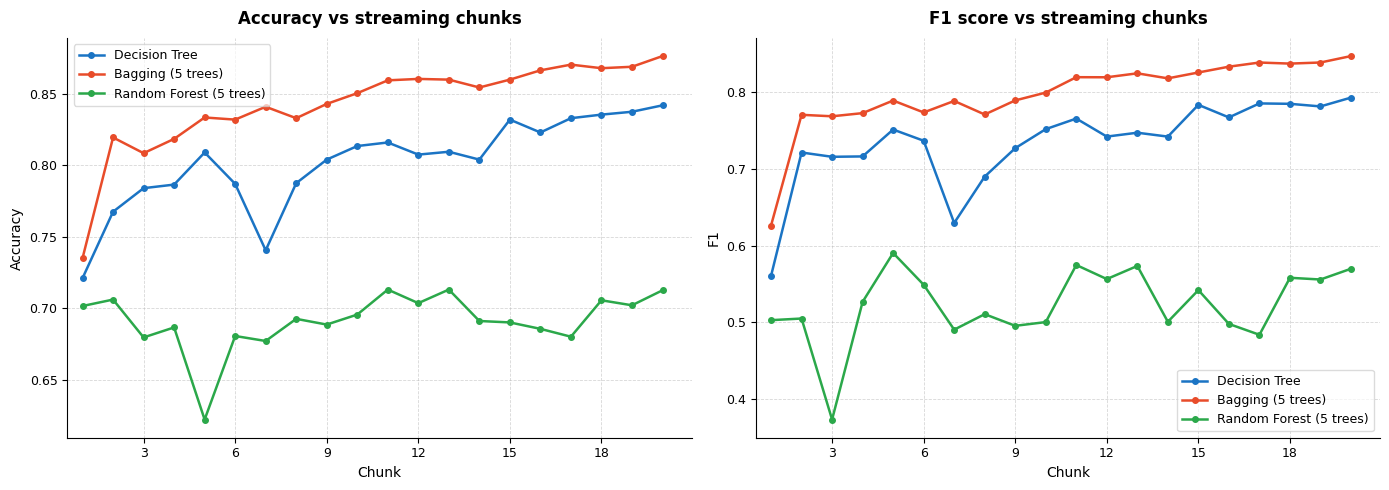

Saved: stream_metrics_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
# CORRECT - pass logs directly, it already has the right structure
visualise.plot_comparison(logs, metric_name='accuracy',
                          title='Accuracy vs streaming chunks',
                          xlabel='Chunk', ylabel='Accuracy', ax=axes[0])

visualise.plot_comparison(logs, metric_name='f1',
                          title='F1 score vs streaming chunks',
                          xlabel='Chunk', ylabel='F1', ax=axes[1])

plt.tight_layout()
plt.savefig('stream_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stream_metrics_comparison.png')

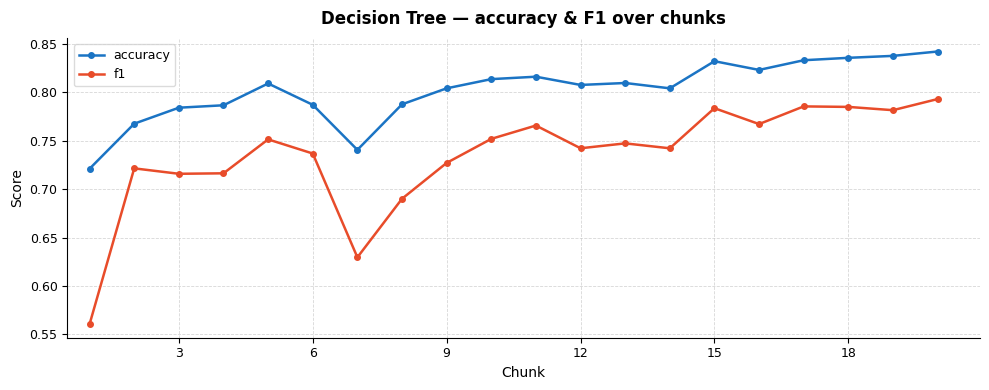

In [10]:
# Plot metrics for the single tree only (accuracy + F1 on one chart)
fig, ax = visualise.plot_metrics(
    {'accuracy': logs['Decision Tree']['accuracy'],
     'f1': logs['Decision Tree']['f1']},
    title='Decision Tree — accuracy & F1 over chunks',
    xlabel='Chunk', ylabel='Score', figsize=(10, 4)
)
plt.show()

## 5. Confusion matrix (final model state)

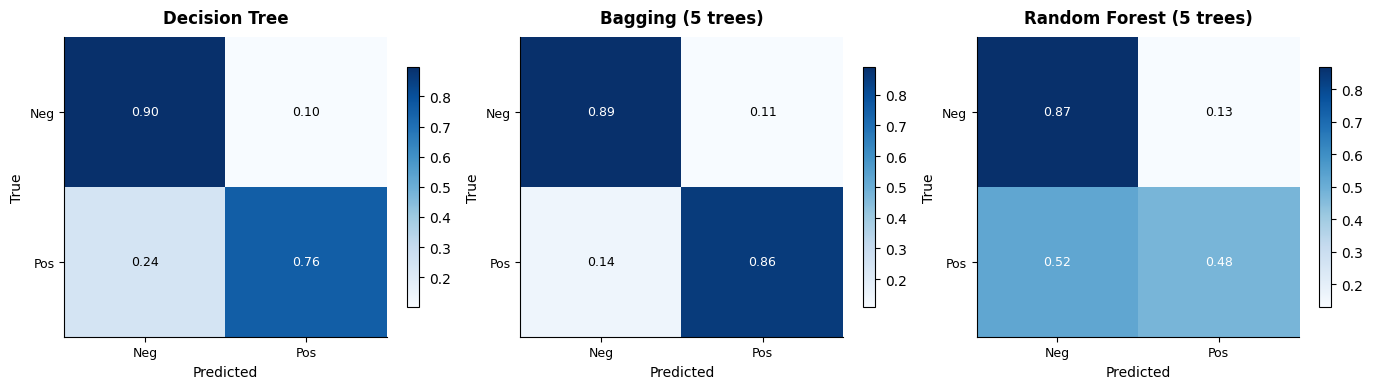

Saved: confusion_matrices.png


In [11]:
X_clean_full = np.where(np.isnan(X), scaler.mean_, X)
X_scaled_full = scaler.transform(X_clean_full)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_scaled_full)
    # Build confusion matrix manually
    cm = np.array([
        [np.sum((y == 0) & (preds == 0)), np.sum((y == 0) & (preds == 1))],
        [np.sum((y == 1) & (preds == 0)), np.sum((y == 1) & (preds == 1))]
    ])
    visualise.plot_confusion_matrix(
        cm, class_names=['Neg', 'Pos'],
        title=name, normalize=True, ax=ax
    )

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

## 6. Tree structure inspection

In [12]:
single_tree = models['Decision Tree']
print(f'Tree depth : {single_tree.depth_}')
print(f'Num leaves : {single_tree.n_leaves_}')
print()
print(visualise.plot_tree_structure(single_tree, max_depth=3))

Tree depth : 10
Num leaves : 50

[SPLIT] f1 <= 0.6146 | class=0 n=100
  ├─ [SPLIT] f0 <= 0.4539 | class=0 n=148
  ├─   ├─ [SPLIT] f0 <= -0.0273 | class=0 n=113
  ├─   ├─   ├─ [SPLIT] f1 <= -0.0929 | class=0 n=499
  ├─   ├─   ├─   ├─ ...
  ├─   ├─   ├─   └─ ...
  ├─   ├─   └─ [SPLIT] f1 <= 0.1913 | class=0 n=35
  ├─   ├─   └─   ├─ ...
  ├─   ├─   └─   └─ ...
  ├─   └─ [SPLIT] f1 <= -1.0003 | class=1 n=44
  ├─   └─   ├─ [SPLIT] f4 <= 0.3864 | class=0 n=32
  ├─   └─   ├─   ├─ ...
  ├─   └─   ├─   └─ ...
  ├─   └─   └─ [SPLIT] f2 <= -0.8071 | class=1 n=37
  ├─   └─   └─   ├─ ...
  ├─   └─   └─   └─ ...
  └─ [SPLIT] f2 <= -1.0581 | class=1 n=52
  └─   ├─ [SPLIT] f5 <= -0.0207 | class=1 n=30
  └─   ├─   ├─ [SPLIT] f2 <= -1.5397 | class=1 n=31
  └─   ├─   ├─   ├─ ...
  └─   ├─   ├─   └─ ...
  └─   ├─   └─ [SPLIT] f0 <= -0.5614 | class=1 n=30
  └─   ├─   └─   ├─ ...
  └─   ├─   └─   └─ ...
  └─   └─ [SPLIT] f2 <= -0.4394 | class=1 n=37
  └─   └─   ├─ [SPLIT] f0 <= -0.6917 | class=1 n=30
  └─  

## 7. ROC Curve

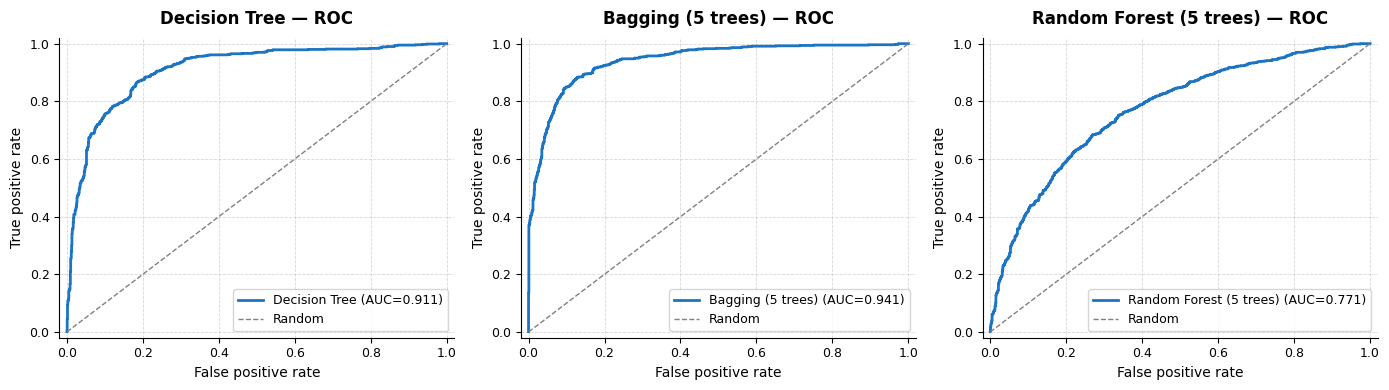

Saved: roc_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    proba = model.predict_proba(X_scaled_full)[:, 1]
    # Compute ROC from scratch (no scikit-learn)
    desc_idx = np.argsort(-proba)
    y_sorted = y[desc_idx]
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    P = y.sum(); NP = len(y) - P
    fpr = fp / NP; tpr = tp / P
    auc_score = float(np.trapezoid(tpr, fpr))
    visualise.plot_roc_curve(fpr, tpr, auc_score=auc_score,
                             label=name, title=f'{name} — ROC', ax=ax)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## 8. Summary

| Model | Final Accuracy | Final F1 |
|-------|---------------|----------|
| Decision Tree | ... | ... |
| Bagging (5 trees) | ... | ... |
| Random Forest (5 trees) | ... | ... |

In [14]:
print('\n=== Final Summary ===')
print(f'{"Model":<32} {"Accuracy":>10} {"F1":>8} {"Depth":>7} {"Leaves":>8}')
print('-' * 68)
for name, model in models.items():
    acc = logs[name]['accuracy'][-1]
    f1 = logs[name]['f1'][-1]
    if hasattr(model, 'depth_'):
        depth = model.depth_
        leaves = model.n_leaves_
    else:
        depths = [t.depth_ for t in model.estimators_]
        depth = f'{np.mean(depths):.1f} (avg)'
        leaves = f'{np.mean([t.n_leaves_ for t in model.estimators_]):.1f} (avg)'
    print(f'{name:<32} {acc:>10.3f} {f1:>8.3f} {str(depth):>7} {str(leaves):>8}')


=== Final Summary ===
Model                              Accuracy       F1   Depth   Leaves
--------------------------------------------------------------------
Decision Tree                         0.842    0.793      10       50
Bagging (5 trees)                     0.876    0.847 8.6 (avg) 50.0 (avg)
Random Forest (5 trees)               0.713    0.570 9.8 (avg) 58.4 (avg)
